_Neural Data Science_

Lecturer: Prof. Dr. Philipp Berens, Dr. Jan Lause

Tutors: Jonas Beck, Kyra Kadhim, Jonathan Oesterle, Julius Würzler

Summer term 2026

Student names: Zhidong Zhang, Yuzhe Han, Bach Nguyen

LLM Disclaimer: Github Copilot was used to help with function calling and structure prompting, Claude and Gemini were used (by different members) to help with function understanding and outcome analysis.

# Coding Lab 8: Neural Morphologies

## Introduction

The anatomical shape of a neuron — its morphology — has fascinated scientists ever since the pioneering work of Cajal (Ramon y Cajal, 1911). A neuron`s dendritic and axonal processes naturally decide what other neurons it can connect to, hence, its shape plays an important role for its function in the circuit. In particular, different functional types of neurons have fundamentally different morphologies.

This notebook will introduce you to the analysis of neural morphologies using the dendrites of over $500$ retinal ganglion cells. The aim is to teach you two different ways of representing morphologies and give you an impression of their repsective strengths and weaknesses.

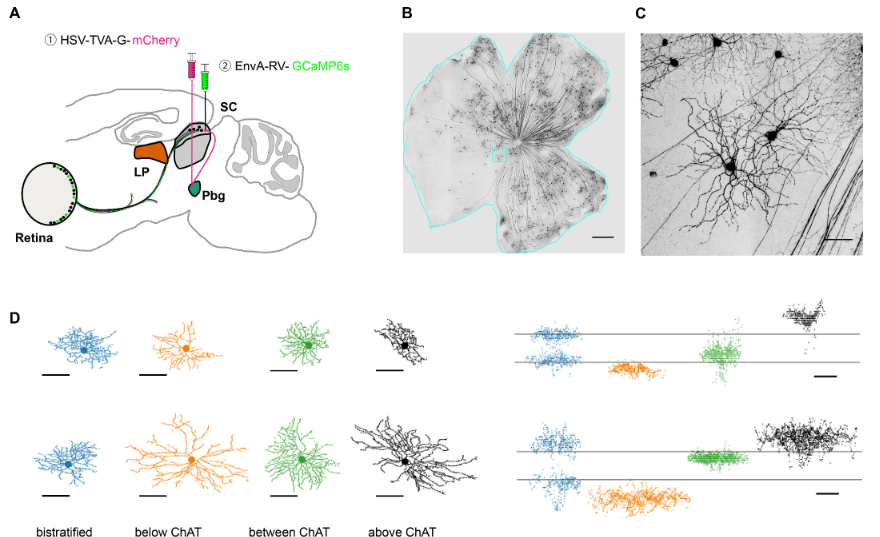

### 1. Data

The data set contains morphological reconstructions of $599$ retinal ganglion cell dendrites with cell type label and projection target to either the parabigeminal (Pbg) or the pulvinar nucleus (LP)([Reinhard et al. (2019)](https://elifesciences.org/articles/50697)). 
Here we only keep cells that map to clusters with more than six cells per cluster which leads to $550$ remaining reconstructions. 

Download the data file `nds_cl_8.zip` from ILIAS and unzip it in a subfolder `../data/`


### 2. Toolbox

We will use MorphoPy (Laturnus, et al., 2020; https://github.com/berenslab/MorphoPy) for this exercise. We recommend to use the Github version, as it is more up-to-date:

```
git clone https://github.com/berenslab/MorphoPy
pip install -e MorphoPy
```

Most of the computations and even some plottings will be handled by MorphoPy. You can learn more about MorphoPy`s APIs in this [tutorial](https://nbviewer.jupyter.org/github/berenslab/MorphoPy/blob/master/notebooks/MORPHOPY%20Tutorial.ipynb). 

In [ ]:
import pandas as pd
import numpy as np
import os

from morphopy.computation import file_manager
from morphopy.neurontree.plotting import show_threeview
from morphopy.neurontree.NeuronTree import NeuronTree as nt

import warnings

warnings.filterwarnings("ignore")

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

%load_ext jupyter_black

%load_ext watermark
%watermark --time --date --timezone --updated --python --iversions --watermark -p sklearnv

Last updated: 2026-06-13 22:59:29 CEST

Python implementation: CPython
Python version       : 3.10.0
IPython version      : 8.39.0

sklearnv: unknown

matplotlib: 3.10.8
morphopy  : 0.7.5
numpy     : 2.2.6
pandas    : 2.3.3
seaborn   : 0.13.2

Watermark: 2.6.0



In [ ]:
plt.style.use("../matplotlib_style.txt")

# Inspect the raw data

#### File format

Morphological reconstructions are typically stored in the SWC file format, a simple text file that holds node information in each row and connects nodes through the `parent` node id. A parent id of -1 indicates no parent, so the starting point of the tree graph, also called the root. 
The `type` label indicates the node type (1: somatic , 2: axonal, 3: dendritic (basal), 4: dendritic (apical), 5+: custom).
The code snippet below loads in one swc file and prints its head. 

You can find a more detailed specification of SWC and SWC+ [here](http://www.neuronland.org/NLMorphologyConverter/MorphologyFormats/SWC/Spec.html) and [here](https://neuroinformatics.nl/swcPlus/).



In [ ]:
def load_swc(filepath: str) -> pd.DataFrame:
    """Loads in the swc located at filepath as a pandas dataframe.

    Args:
        filepath (str): The path to the swc file.

    Returns:
        pd.DataFrame: A pandas dataframe containing the swc file.
    """
    swc = pd.read_csv(
        filepath,
        delim_whitespace=True,
        comment="#",
        names=["n", "type", "x", "y", "z", "radius", "parent"],
        index_col=False,
    )
    return swc


# define color for each cluster
colors = sns.color_palette("rainbow_r", n_colors=14)
colors = np.array(colors)

In [ ]:
# import swc file
PATH = "../data/nds_cl_8/"
data_path = PATH + "reconstructions/soma-centered/"
filename = "0060_00556_3R_C02_01.swc"
filepath = data_path + filename

swc = load_swc(filepath)
swc.head()

,n,type,x,y,z,radius,parent
0,1,1,0.00,0.00,0.49,1.0,-1
1,2,3,-0.16,0.02,0.52,1.0,1
2,3,3,0.20,0.03,0.51,1.0,1
3,4,3,0.11,-0.19,0.47,1.0,1
4,5,3,0.17,-0.48,0.49,1.0,4


The labels `x`, `y`, and `z` hold a node`s 3D coordinate in tracing space (here in microns). For reasons of simplicity we will work with reconstructions that are soma centered in XY.

The assigned cell type labels are stored in the file `rgc_labels.csv` and indexed by their `Cell_nr`. In this file you find three different cluster assignments: `clusterA` is the assignment of the authors (clus1 -- clus14), `clusterB` is the respective cluster identifier of the [Eyewire museum](http://museum.eyewire.org) (also see [Bae et al. 2018](https://www.sciencedirect.com/science/article/pii/S0092867418305725)), and `clusterC` are molecular or functional label names when available. 
We have formatted the cluster assignments of the authors (`clusterA`) into integer values and stored them in the column `cluster`, which we will use in the following.

In [ ]:
labels = pd.read_csv(PATH + "rgc_labels.csv", index_col=0)

cluster_label, cluster_counts = np.unique(labels["cluster"], return_counts=True)
labels.head()

,Cell_nr,projection_site,clusterA,clusterB,clusterC,cluster
1,2,LP,clus6,4ow,tOFFα,6
2,3,LP,clus2,2an,F-mini-OFF,2
3,4,LP,clus1,1wt,sOFFα,1
4,6,LP,clus7,5to,NaN,7
5,7,LP,clus10,6sn,NaN,10


## Task 1: Plotting individual morphologies

Load data using `file_manager` and plot individual morphologie using `show_threeview` of from `MorphoPy`. It plots all three planar views on the reconstruction. 

Here, XY shows the planar view on top of the retina, and Z denotes the location within the inner plexiform layer (IPL).

Noted, by default, the `file_manager` loads data with `pca_rot=True` and `soma_center=True`. For the all the exercise in this Coding Lab, it`s better to set both of them as `False`. 

*Grading: 2pts*

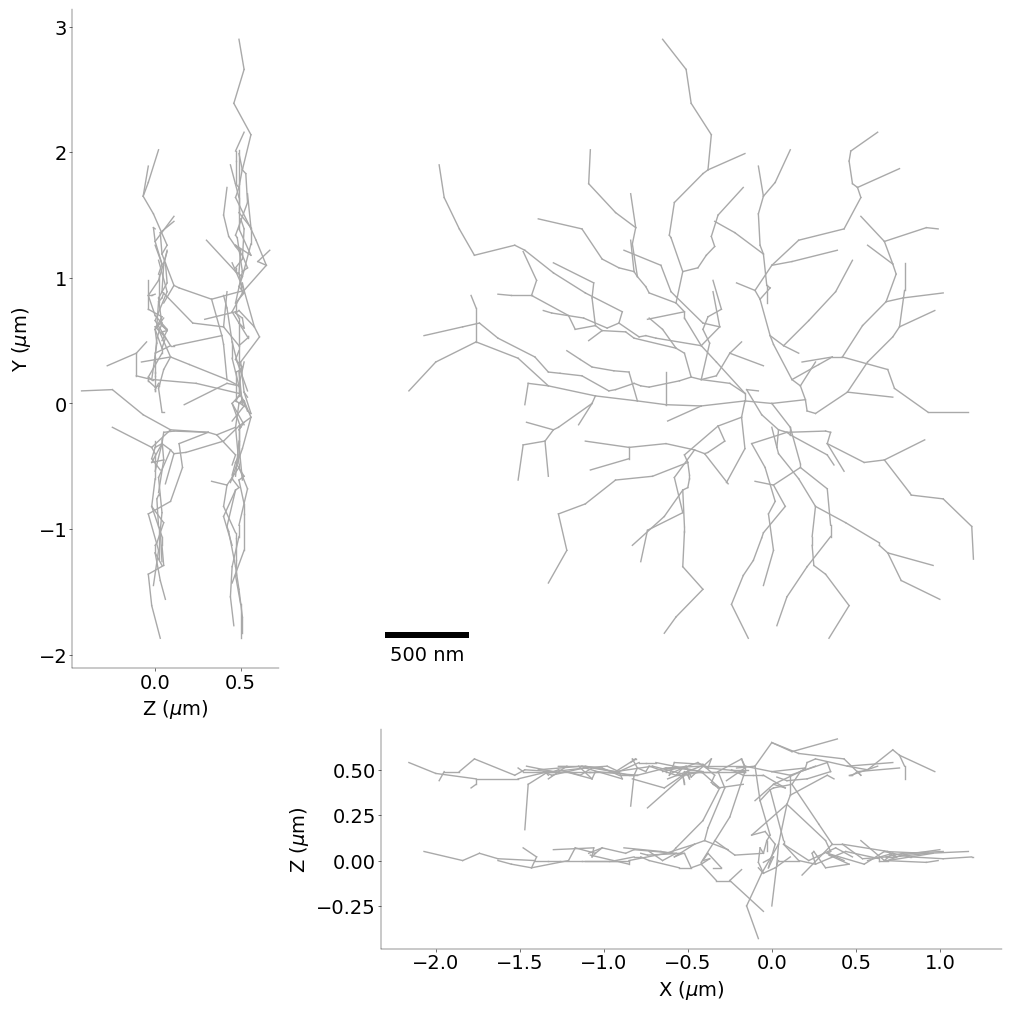

In [ ]:
# ----------------------------------------------------------------
# load the example cell "0060_00556_3R_C02_01" with `file_manager`
# from morphology (0.5 pts)
# ----------------------------------------------------------------
tree = file_manager.load_swc_file(filepath, soma_center=False, pca_rot=False)
# -------------------------------------
# plot all three planar views (0.5 pts)
# -------------------------------------
fig = plt.figure(figsize=(10, 10))
show_threeview(tree, fig)

### Questions (0.5 pts)

1) Describe the dendritic structure of this neuron. How is it special? Can you even give a technical term for its appearance?

**Answer:**
>  It spread unifromly in the x-y planar view, and shows clear two-layer plexiform structure. It can be described as a planar stellate stratified structure .

SWC files are a compact way for storing neural morphologies but their graph structure makes them difficult to handle for current machine learning methods. We, therefore, need to convert our reconstructions into a reasonable vector-like representations. 

Here we will present two commonly chosen representations: Morphometric statistics and density maps


In [ ]:
# load all reconstructions. Note: files are sorted by cell number
def load_files(path: str) -> list[nt]:
    """Returns list of NeuronTrees for all .swc files in `path`.
    The reconstructions should be sorted ascendingly by their filename.

    Args:
        path (str): The path to the folder containing the reconstructions.

    Returns:
        list[nt]: An object array of NeuronTrees containing all reconstructions at `path`.
    """
    neurons = []
    # ----------------------------------------------------------
    # use `file_manager` to import all reconstructions (0.5 pts)
    # Note the list should be sorted by filename.
    # ----------------------------------------------------------
    swc_filenames = [
        f for f in os.listdir(path) if f.endswith(".swc")
    ]  # load all swc files
    swc_filenames.sort()  # using `<` directly, as the filenames are formatted

    for filename in swc_filenames:
        tree = file_manager.load_swc_file(path + filename)
        neurons.append(tree)

    return neurons


neurons = load_files(data_path)
print("Number of reconstructions: ", len(neurons))

Number of reconstructions:  550


## Task 2: Morphometric statistics

Morphometric statistics denote a set of hand-crafted single valued features such as `soma radius`, `number of tips` or `average branch angle`. For a more detailed explanation of morphometrics please refer to the [MorphoPy documentation](https://github.com/berenslab/MorphoPy#morphometric-statistics).

*Grading: 4pts*

First, let`s compute the feature-based representation for each cell using the function `compute_morphometric_statistics` of the MorphoPy package which computes a predefined set of $28$ statistics.


In [ ]:
from morphopy.computation.feature_presentation import compute_morphometric_statistics

# --------------------------------------------------------------------------
# 1. extraction the morphometric statistics for the entire data set (0.5 pts)
# --------------------------------------------------------------------------

ms_list = [compute_morphometric_statistics(tree) for tree in neurons]
# -----------------------------------------------------------------------------------
# 2. concatenate data into one pd.DataFrame and set the `Cell_nr`` as index (0.5 pts)
# -----------------------------------------------------------------------------------

morphometric_statistics = pd.concat(ms_list, ignore_index=True)

# get Cell_nr
import re

swc_filenames = [f for f in os.listdir(data_path) if f.endswith(".swc")]
swc_filenames.sort()
Cell_nrs = [int(re.split(r"_", filename)[0]) for filename in swc_filenames]
morphometric_statistics.index = pd.Index(Cell_nrs, name="Cell_nr")

morphometric_statistics.head()

,branch_points,width,depth,height,tips,stems,total_length,avg_thickness,max_thickness,total_surface,...,median_intermediate_segment_pl,median_terminal_segment_pl,log_max_tortuosity,log_min_tortuosity,log_median_tortuosity,max_branch_angle,min_branch_angle,mean_branch_angle,max_degree,tree_asymmetry
Cell_nr,,,,,,,,,,,,,,,,,,,,,
2,66.0,4.12,5.96,0.54,69.0,3.0,65.793587,1.0,1.0,413.393297,...,0.334798,0.456196,0.253612,0.0,0.005766,124.974479,7.286952,50.402105,3.0,0.726199
3,18.0,3.07,2.66,0.68,23.0,1.0,18.657365,1.0,1.0,117.227681,...,0.345014,0.349991,0.285133,0.0,0.000564,110.367090,18.036960,57.088068,3.0,0.738502
4,54.0,5.05,3.53,0.72,61.0,6.0,41.349847,1.0,1.0,259.808753,...,0.202111,0.281069,0.312270,0.0,0.000000,131.508679,25.596621,59.646776,3.0,0.706943
6,36.0,3.45,4.38,0.49,39.0,4.0,32.249580,1.0,1.0,202.630089,...,0.217084,0.412995,0.251400,0.0,0.017747,130.034126,16.436535,54.683803,2.0,0.601296
7,31.0,4.13,3.86,0.58,40.0,7.0,34.647295,1.0,1.0,217.695372,...,0.248395,0.530086,0.217363,0.0,0.024678,104.036243,2.970445,55.498150,3.0,0.579942


Now let`s visualize the data.

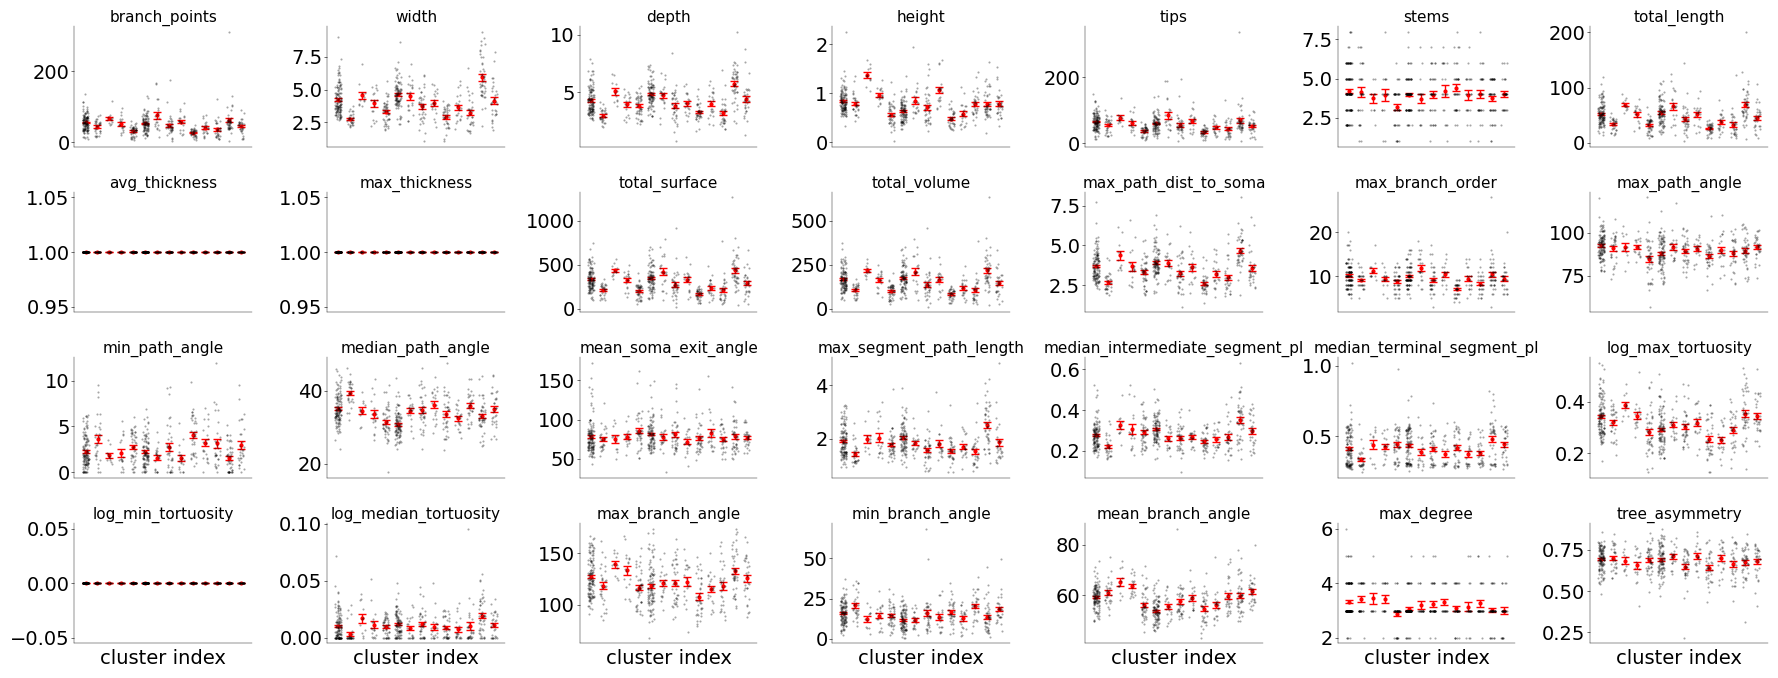

In [ ]:
features = morphometric_statistics.columns.values

fig, axes = plt.subplots(4, 7, figsize=(18, 7))
axes = axes.flatten()

# -----------------------------------------------------------
# Create a scatter/strip plot for each morphometric statistic
# showing how it varies across clusters. (2 pts)
# -----------------------------------------------------------
for i, ax in enumerate(axes):
    feature = features[i]

    plot_data = []
    for cluster_id in cluster_label:
        cells = labels[labels["cluster"] == cluster_id]["Cell_nr"]
        values = morphometric_statistics.loc[cells, feature]
        plot_data.append(
            pd.DataFrame(
                {
                    "cluster": cluster_id,
                    "value": values.values,
                }
            )
        )

    plot_df = pd.concat(plot_data, ignore_index=True)

    sns.stripplot(
        data=plot_df,
        x="cluster",
        y="value",
        ax=ax,
        jitter=0.25,
        alpha=0.35,
        size=3,
        color="black",
    )

    summary = plot_df.groupby("cluster")["value"].agg(["mean", "sem"]).reset_index()
    ax.errorbar(
        x=np.arange(len(summary)),
        y=summary["mean"],
        yerr=summary["sem"],
        fmt=".",
        color="red",
        capsize=3,
        markersize=4,
        linewidth=1,
    )
    ax.set_xticks([])
    if i > 20:
        ax.set_xlabel("cluster index")
    else:
        ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title(feature, fontsize=11)

plt.tight_layout()
plt.show()

### Questions (1 pt)

1) Which statistics separate clusters well? Which can be removed? (tips: there are 5 uninformative features)

**Answer:**

> The `stems`, `avg_thickness`, `max_thickness`, `log_min_tortuosity`, `max_degree` are uninformative features that can be removed. Other feartures all show difference across clusters, more or less, but almost none of them can separate clusters well seperately.

2) More generally, what do morphometric statistics capture well? What are their advantages, what might be their downsides? Briefly explain.

**Answer:**
> The morphometric statistics capture the global size well, e.g., width, depth, and volume. It extract the general quantitative features, but as a summary, it loss the detailed information like relative spatial relation.

## Task 3: Density maps

Density maps project a neuron`s 3D point cloud ($x$, $y$, $z$) onto a plane or an axis, and bin the projected point cloud into a fixed number of bins. Hereby, the binning controls how much global or local information is kept, which majorly affects the results.

**Exercise:** Compute the density maps of all neurons onto all cardinal planes and axes using the method `compute_density_maps`. You can manipulate the parameters for the density maps via the dictonary `config`. 
Make sure that you normalize the density maps globally and bin each direction into $20$ bins.
You are welcome to explore, how the different projections look like but we will only use the z-projection for further analysis.


Possible parameters to pass are:

- `distance`: (default=1, in microns) determines the resampling distance.
- `bin_size`: (default=20, in microns). If set the number of bins will be computed such that one bin 
spans `bin_size` microns. This is overwritten when `n_bins_x/y/z` is set!
- `n_bins_x/y/z`: (default=None) specifies the number of bins for each dimension. If set it will overwrite the 
`bin_size` flag.
- `density`: (default=True) bool to specify if a density or counts are returned.
- `smooth`: (default=True) bool to trigger Gaussian smoothing.
- `sigma`: (default=1) determines std of the Gaussian used for smoothing. The bigger the sigma the more smoothing occurs. If smooth is set to False this parameter is ignored. 
- `r_min_x/y/z`: (in microns) minimum range for binning of x, y, and z. This value will correspond to the 
minimal histogram edge. 
- `r_max_x/y/z`: (in microns) maximum range for binning for x, y, and z. This value will correspond to the 
maximal histogram edge. 

*Grading: 4pts*

In [ ]:
# For further analysis we will remove uninformative features and z-score along each statistic
# features_to_drop = [
#     "avg_thickness",
#     "max_thickness",
#     "total_surface",
#     "total_volume",
#     "log_min_tortuosity",
# ]
features_to_drop = [
    "avg_thickness",
    "max_thickness",
    "log_min_tortuosity",
    "stems",
    "max_degree",
]
morphometric_data = morphometric_statistics.drop(features_to_drop, axis=1)

feature_remained = morphometric_data.columns.values

# z-score morphometrics and remove nans and uninformative features
morphometric_data = (
    morphometric_data - morphometric_data.mean()
) / morphometric_data.std()
morphometric_data[morphometric_data.isna()] = 0
morphometric_data = morphometric_data.values  # nparray (num_neurons, num_features)

In [ ]:
# ------------------------------------------------------------------------------------
# Find the minimal and maximal x,y,z - coordinates of the reconstructions to normalize
# the density maps globally using r_min_x/y/z and r_max_x/y/z and print them  for
# each direction. (1 pt)
# ------------------------------------------------------------------------------------
r_max = np.array([])
r_min = np.array([])

for tree in neurons:
    pos_arr = []
    for node in tree._G.nodes:
        pos_arr.append(tree._G.nodes[node]["pos"])
    pos_arr = np.stack(pos_arr, axis=0)  # (num_nodes, 3)

    if r_min.any():
        r_min = np.minimum(r_min, pos_arr.min(axis=0))
    else:
        r_min = pos_arr.min(axis=0)

    if r_max.any():
        r_max = np.maximum(r_max, pos_arr.max(axis=0))
    else:
        r_max = pos_arr.max(axis=0)

print("r_max: ", r_max)
print("r_min: ", r_min)

r_max:  [5.14 5.36 1.59]
r_min:  [-6.34 -5.49 -2.26]


In [ ]:
from morphopy.computation.feature_presentation import compute_density_maps

config_global = dict(
    # ---------------------------------------------------------------------------------
    # complete the config dict and compute the z-density maps for each neuron (1 pts)
    # ---------------------------------------------------------------------------------
    distance=1,
    n_bins_x=20,
    n_bins_y=20,
    n_bins_z=20,
    density=True,
    smooth=False,
    sigma=1,
    r_max_x=r_max[0],
    r_max_y=r_max[1],
    r_max_z=r_max[2],
    r_min_x=r_min[0],
    r_min_y=r_min[1],
    r_min_z=r_min[2],
)

density_maps = {
    Cell_nrs[i]: compute_density_maps(neurons[i], config_params=config_global)
    for i in range(len(neurons))
}  # {Cell_nr: density}


# extract the Z-density map
dm_z = {
    cell_id: density["z_proj"] for (cell_id, density) in density_maps.items()
}  # {Cell_nr: z-density}

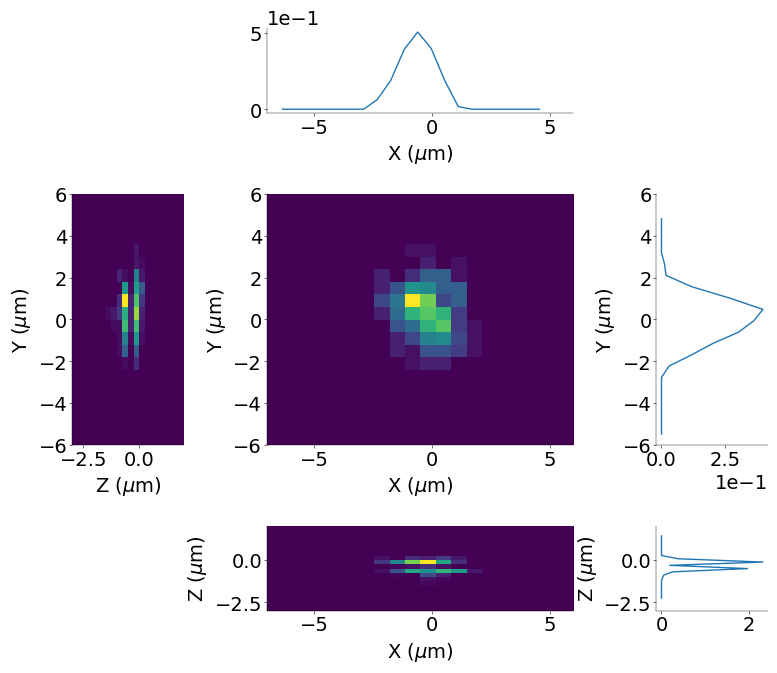

In [ ]:
from morphopy.computation.feature_presentation import plot_density_maps

fig = plot_density_maps(density_maps[60])

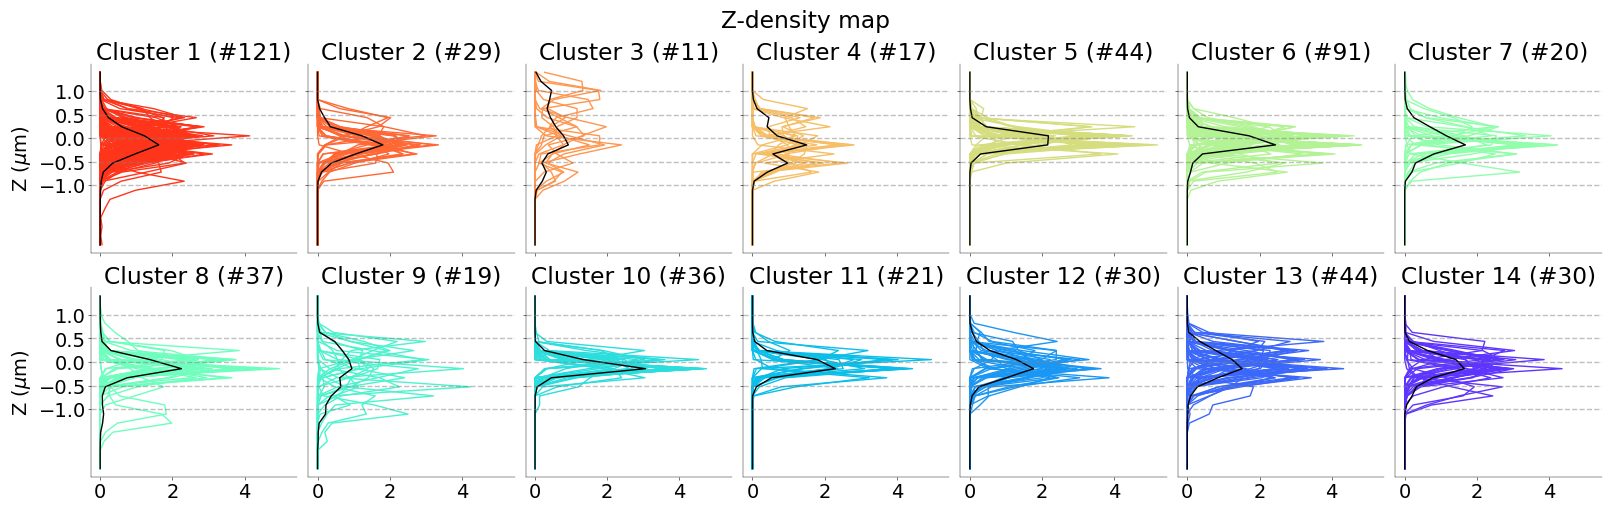

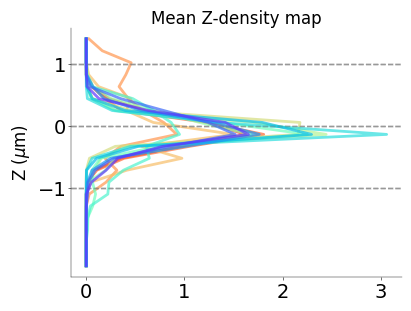

In [ ]:
# --------------------------------------------------------------------
# plot the Z-density maps and their means sorted by class label (1 pt)
# Note: make sure the clusters are comparable.
# --------------------------------------------------------------------

fig, axes = plt.subplots(2, 7, figsize=(16, 5), sharex=True, sharey=True)
axes = axes.flatten()

cell_cluster_groups = labels.groupby("cluster")["Cell_nr"].apply(lambda x: x.values)

z_means_all = []
for cluster_id in cell_cluster_groups.index:
    cells = cell_cluster_groups[cluster_id]

    z_datas = np.array(
        [dm_z[i]["data"] for i in cells]
    )  # (num_neurons, bins) values in the bins
    z_edges = dm_z[cells[0]]["edges"][0][:-1]  # edges of bining

    z_means = z_datas.mean(axis=0)  # the mean z-density
    z_means_all.append(z_means)

    ax = axes[cluster_id - 1]
    for data in z_datas:
        ax.plot(data, z_edges, color=colors[cluster_id - 1])
    ax.plot(z_means, z_edges, color="black")

    yticks = [-1, -0.5, 0, 0.5, 1]
    ax.set_yticks(yticks)
    for y in yticks:
        ax.axhline(y, linestyle="--", color="gray", alpha=0.5)

    ax.set_title(f"Cluster {cluster_id} (#{len(cells)})")
    if cluster_id in [1, 8]:
        ax.set_ylabel("z".capitalize() + r" ($\mu$m)")
plt.suptitle("Z-density map")
plt.show()

fig, ax = plt.subplots(figsize=(4, 3))
for i, z_means in enumerate(z_means_all):
    ax.plot(z_means, z_edges, color=colors[i], linewidth=2, alpha=0.7)
    ax.set_ylabel("z".capitalize() + r" ($\mu$m)", fontsize=12)
    ax.set_title("Mean Z-density map", fontsize=12)

    yticks = [-1, 0, 1]
    ax.set_yticks(yticks)
    for y in yticks:
        ax.axhline(y, linestyle="--", color="gray", alpha=0.1)
plt.show()

### Questions (1 pt)

1) What does the Z-density map tell you about the cell types? Can you identify a trend in the density maps?

**Answer:**

> It tells the layer structure of the cell types. Specifically, it shows that some cell types tend to be more distributed with more than 1 peak, e.g., Cluster 3 and 4, while other cell types tend to be more concentrated at the soma with a single peak, e.g., Cluster 1 and 2. 

2) Which cluster(s) would you expect the cell from Task 1 to come from and why?

**Answer:**

> Cluster 4 or 9, because their mean z-densities both show a peak at around $\pm$ 0.5 $\mu m$ besides the peak at 0 $\mu m$, which aligns with the 2-layer structure of teh cell from Task 1.


## Task 4: 2D embedding using t-SNE


Embed both data, the morphometric statistics and the density maps, in 2D using t-SNE and color each embedded point by its cluster assignment.

*Grading: 3 pts*

In [ ]:
from openTSNE import TSNE

# ----------------------------------------------------------------------
# Fit t-SNE with morphometric statistics and density maps (0.5 + 0.5 pt)
# Note that this can take a bit to run. (use perplexity=100
# and a random state of 17)
# ----------------------------------------------------------------------

tsne = TSNE(n_components=2, perplexity=100, random_state=17)

from time import time

print("===== Morphometric statistics =====")
print("Shape of data: ", morphometric_data.shape)

begin_time = time()
embedding_morphometric = tsne.fit(morphometric_data)
end_time = time()
print(f"Time used: {end_time - begin_time:.3f} s")


print("===== Density maps (Z) =====")
z_density_data = np.array([dm_z[cell_id]["data"] for cell_id in Cell_nrs])
xy_density_data = np.array(
    [density_maps[cell_id]["xy_proj"]["data"].flatten() for cell_id in Cell_nrs]
)
density_maps_data = np.concat([z_density_data, xy_density_data], axis=1)
# print("Shape of data: ", density_maps_data.shape)
print("Shape of data: ", z_density_data.shape)

begin_time = time()
embedding_zdensity_maps = tsne.fit(z_density_data)
end_time = time()
print(f"Time used: {end_time - begin_time:.3f} s")

# Only Z-density is required here!

===== Morphometric statistics =====
Shape of data:  (550, 23)
Time used: 4.290 s
===== Density maps (Z) =====
Shape of data:  (550, 20)
Time used: 4.364 s


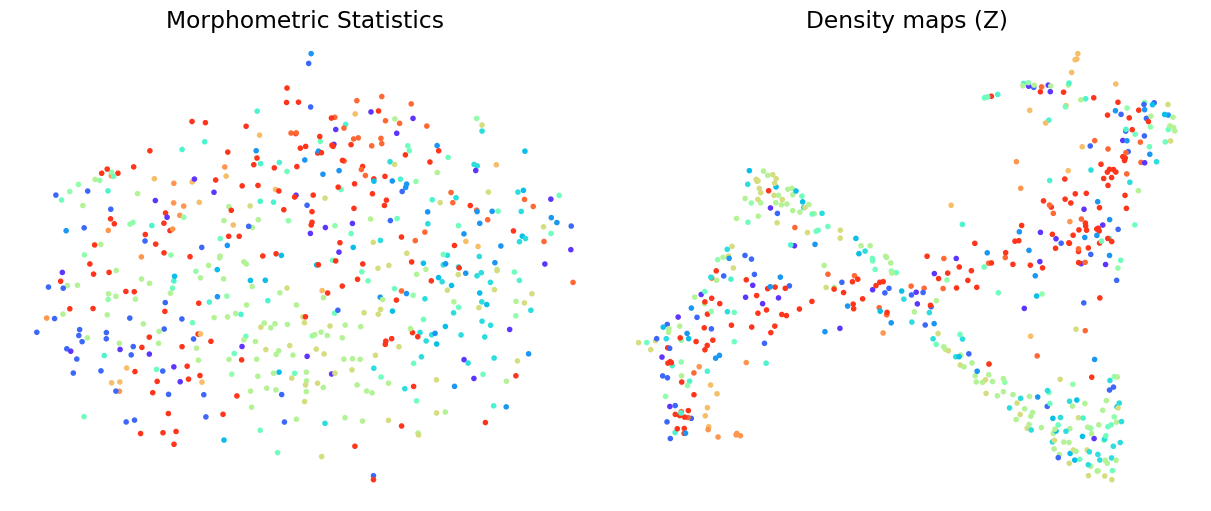

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")

# ----------------------------------------------------------------------------
# plot tsne fits for both morpometric statistics and z-projected density maps.
# Color the points appropriately and answer the questions below. (2 pt)
# ----------------------------------------------------------------------------

cluster_idx = labels["cluster"].to_numpy().astype(int) - 1
cluster_colormap = colors[cluster_idx]

axes[0].scatter(
    embedding_morphometric[:, 0], embedding_morphometric[:, 1], c=cluster_colormap
)
axes[1].scatter(
    embedding_zdensity_maps[:, 0], embedding_zdensity_maps[:, 1], c=cluster_colormap
)

axes[0].set_title("Morphometric Statistics")
axes[1].set_title("Density maps (Z)")

for i in range(2):
    axes[i].axis("off")
plt.show()

### Questions:
1) Which representation produces the better clustering? Why could this be the case?

**Answer:**
> The one by density maps. Because the density maps remains more detailed structure of the neurons, therefore supports better seperation between different cell types.

2) What are the advantages of morphometric statistics over density maps 

**Answer:**
> They are more lower-dimensional to make the computation faster. Also, they provides more interpretable features that all have clear biological meaning.

3) What are the advantages of density maps over morphometric statistics 

**Answer:**
> It remains more information about the neurons' morphology. Although its feature dimension is larger, especially if we make use of all 3 dimensions of the density map, the feature space is very sparse and can be reduced to lower dimension. The time used for t-SNE is also not too larger than the other.

## Task 5: Predicting the projection site

The relationship between neuronal morphology and functional specialization is well-established in neurobiology. Hence, we expect distinct functional domains within the thalamus to exhibit corresponding morphological signatures. In this analysis, we aim to predict the thalamic projection site (`labels[`projection_site`]`) of individual neurons based on their morphological characteristics. Fit a logistic regression on both morphological representations and report its average cross validated (cv=5) prediction accuracy for each. Which representation works better to recover the prediction target? Which features are most relevant for that prediction?

You can use `LogisticRegressionCV` of the scikit-learn library directly. To understand the relevance of individual features plot the fitted linear coefficients. Note, since the classes are imbalanced make sure to report the balanced prediction accuracy.

*Grading: 2 pts*

In [ ]:
print(np.unique(labels["projection_site"]))
y_all = labels["projection_site"].replace(["LP", "Pbg"], [1, 0]).values
y_all.shape

['LP' 'Pbg']


(550,)

In [ ]:
from sklearn.linear_model import LogisticRegressionCV

# -----------------------------------------------------------------------------
# Fit a logistic regressor to predict the projection site based on both feature
# representations and print the avg. prediction accuracy (1 pt)
# -----------------------------------------------------------------------------

cv = LogisticRegressionCV(cv=5)


print("===== Morphometric statistics =====")
cv.fit(morphometric_data, y_all)
avg_acc_stat = cv.scores_[1].mean()
print(f"Avg. accruracy: {avg_acc_stat:.3f}")
coef_stat = cv.coef_[0]

print("===== Density maps (Z) =====")
cv.fit(z_density_data, y_all)
avg_acc_zdensity = cv.scores_[1].mean()
print(f"Avg. accruracy: {avg_acc_zdensity:.3f}")
coef_zdensity = cv.coef_[0]


print("===== Density maps (Z & XY) =====")
cv.fit(density_maps_data, y_all)
avg_acc_density = cv.scores_[1].mean()
print(f"Avg. accruracy: {avg_acc_density:.3f}")
coef_density = cv.coef_[0]

===== Morphometric statistics =====
Avg. accruracy: 0.720
===== Density maps (Z) =====
Avg. accruracy: 0.629
===== Density maps (Z & XY) =====
Avg. accruracy: 0.669


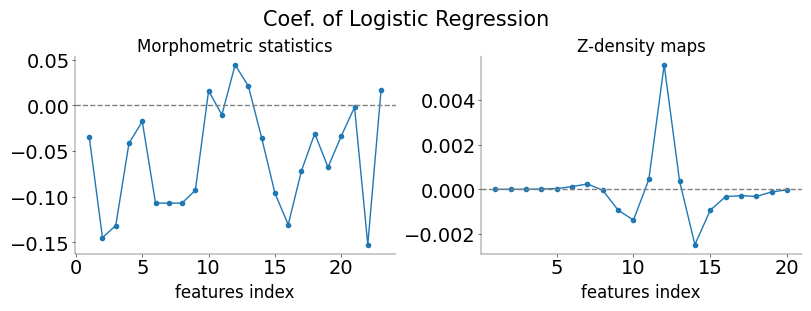

Top 4 relevant features (Morphometric statistics)
------------------------------------------
feature                              coef
------------------------------------------
mean_branch_angle                  -0.152
width                              -0.145
depth                              -0.132
median_intermediate_segment_pl     -0.131


In [ ]:
# ---------------------------------------------------------------------------
# Plot the fitted linear coefficients for both of the feature representations
# and answer the question below. (1 pt)
# ---------------------------------------------------------------------------


fig, axes = plt.subplots(1, 2, figsize=(8, 3))

axes[0].plot(np.arange(1, len(coef_stat) + 1), coef_stat, marker=".")
axes[0].axhline(0, color="gray", linestyle="--")
axes[0].set_title("Morphometric statistics", fontsize=12)
axes[0].set_xlabel("features index", fontsize=12)

axes[1].plot(np.arange(1, len(coef_zdensity) + 1), coef_zdensity, marker=".")
axes[1].axhline(0, color="gray", linestyle="--")
axes[1].set_title("Z-density maps", fontsize=12)
axes[1].set_xlabel("features index", fontsize=12)

fig.suptitle("Coef. of Logistic Regression", fontsize=15)
plt.show()


sort_indices_stat = np.absolute(coef_stat).argsort()[::-1]
print("Top 4 relevant features (Morphometric statistics)")
print("-" * 42)
print(f"{'feature':<30} {'coef':>10}")
print("-" * 42)
for i in sort_indices_stat[:4]:
    print(f"{feature_remained[i]:<30} {coef_stat[i]:>10.3f}")

### Question:

1) Which morphometrics are informative on the projection site?

**Answer:**

> The morphometric statistics are better on predicting the projection target than the density maps.

## Further references

Other ways to represent and compare morphologies are
* Persistence: [Description](https://link.springer.com/article/10.1007/s12021-017-9341-1) and [application on somatosensory pyramidal cell dendrites](https://academic.oup.com/cercor/article/29/4/1719/5304727) by Kanari et al. 2018

* Tree edit distance: [Heumann et al. 2009](https://link.springer.com/article/10.1007/s12021-009-9051-4)

* Sequential encoding inspired by BLAST: [Encoding](https://link.springer.com/article/10.1186/s12859-015-0604-2) and [similarity analysis on cortical dendrites](https://link.springer.com/article/10.1186/s12859-015-0605-1) by Gilette et al. 2015

* Vector point clouds: [BlastNeuron: Wan et al. 2015](https://link.springer.com/article/10.1007/s12021-015-9272-7)